Saving movie_dataset.xlsx to movie_dataset.xlsx
First 5 Rows:
             Title     Genre              Director  Year  Rating  \
0        Inception    Sci-Fi     Christopher Nolan  2010     8.8   
1  The Dark Knight    Action     Christopher Nolan  2008     9.0   
2     Interstellar    Sci-Fi     Christopher Nolan  2014     8.7   
3         Parasite  Thriller          Bong Joon Ho  2019     8.5   
4    The Godfather     Crime  Francis Ford Coppola  1972     9.2   

   Budget (Million USD)  Revenue (Million USD)  
0                 160.0                    839  
1                 185.0                   1006  
2                 165.0                    731  
3                  11.0                    258  
4                   6.0                    250  

Dataset Shape:
(15, 7)

Column Names:
Index(['Title', 'Genre', 'Director', 'Year', 'Rating', 'Budget (Million USD)',
       'Revenue (Million USD)'],
      dtype='object')

Data Types:
Title                     object
Genre           

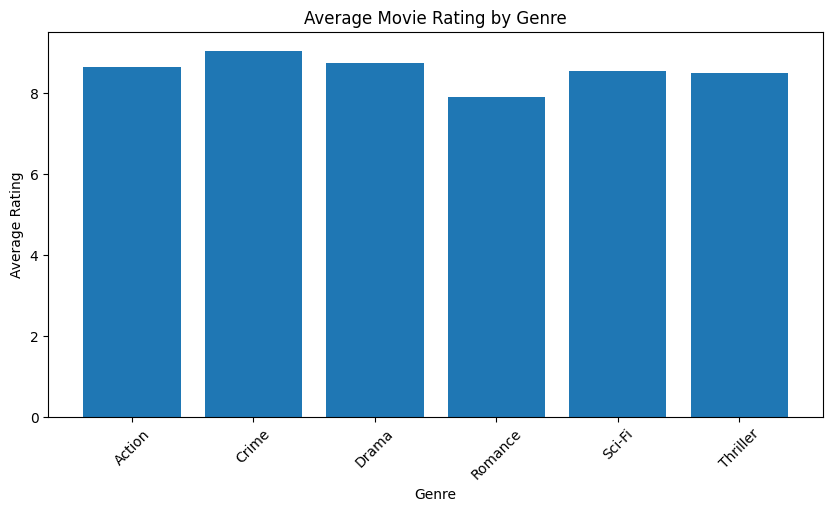

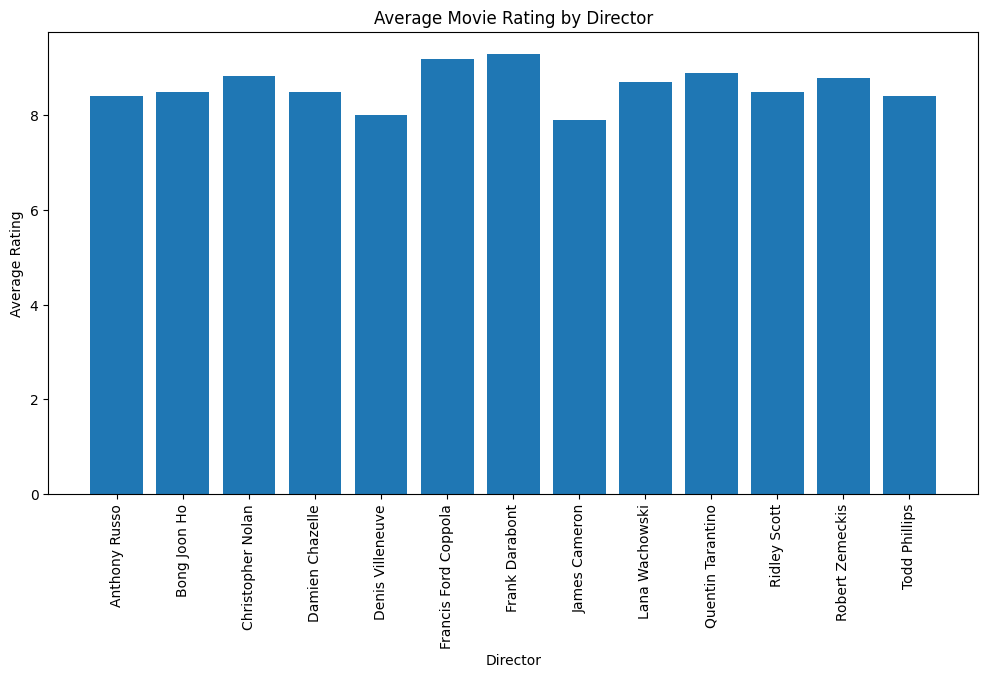

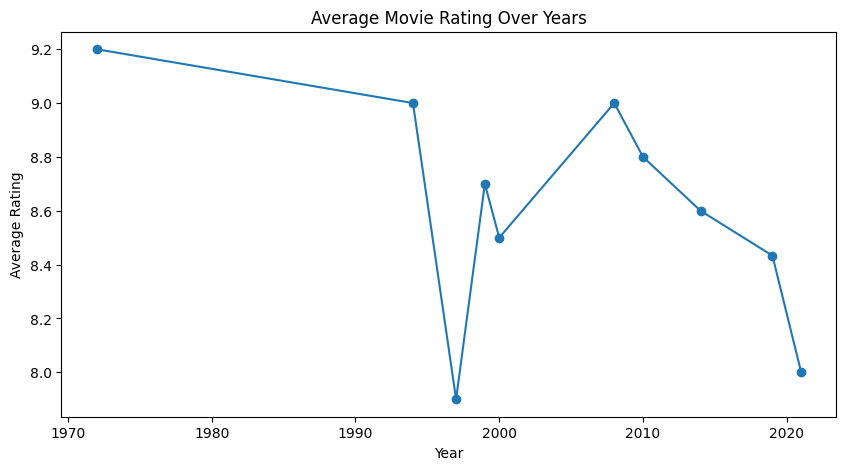

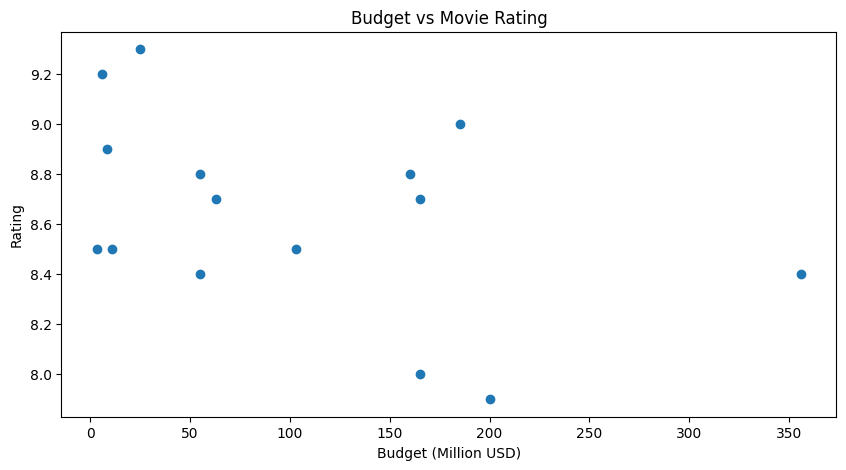

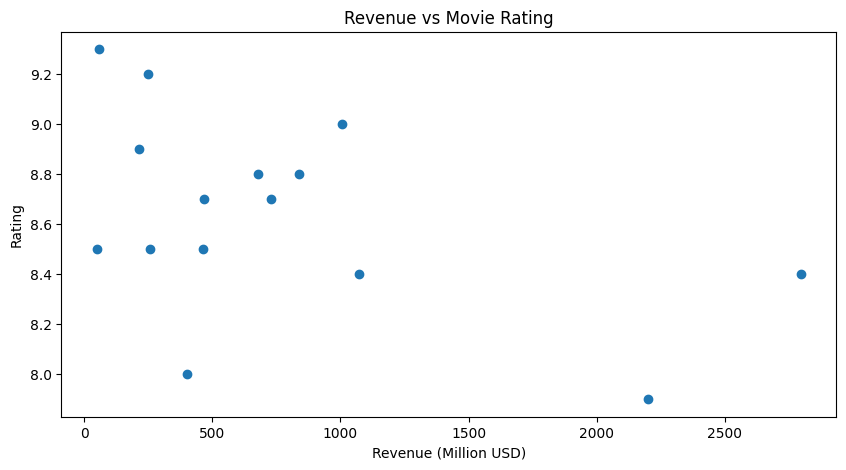

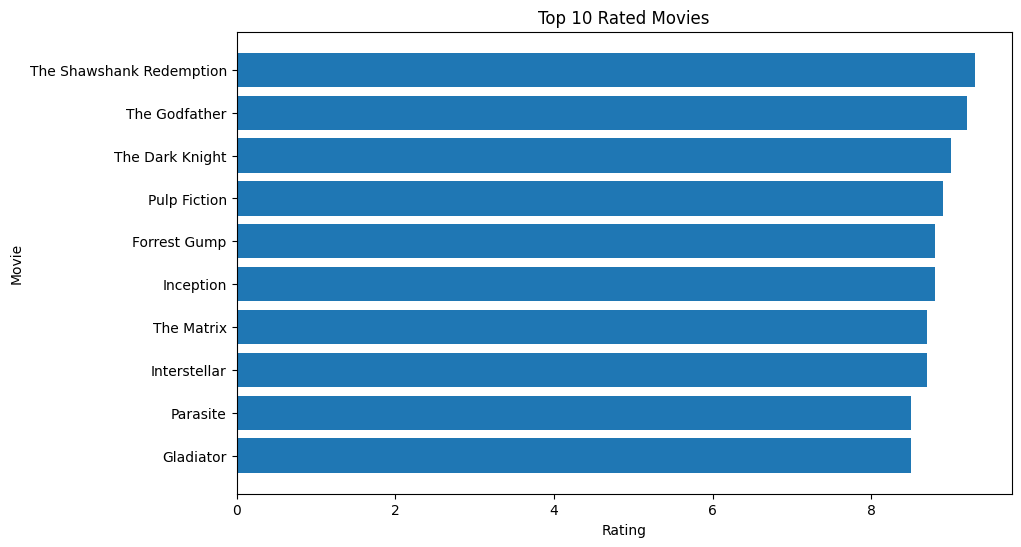


Top 10 Rated Movies:
                       Title  Rating     Genre              Director  Year
12  The Shawshank Redemption     9.3     Drama        Frank Darabont  1994
4              The Godfather     9.2     Crime  Francis Ford Coppola  1972
1            The Dark Knight     9.0    Action     Christopher Nolan  2008
13              Pulp Fiction     8.9     Crime     Quentin Tarantino  1994
0                  Inception     8.8    Sci-Fi     Christopher Nolan  2010
5               Forrest Gump     8.8     Drama       Robert Zemeckis  1994
2               Interstellar     8.7    Sci-Fi     Christopher Nolan  2014
9                 The Matrix     8.7    Sci-Fi        Lana Wachowski  1999
3                   Parasite     8.5  Thriller          Bong Joon Ho  2019
10                 Gladiator     8.5    Action          Ridley Scott  2000

Correlation:
Budget vs Rating: -0.42394263855067404
Revenue vs Rating: -0.47192903162595706

Key Findings:
Highest Rated Movie: The Shawshank Redemption

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)

# Upload dataset
from google.colab import files

uploaded = files.upload()

# Load Excel file
df = pd.read_excel("movie_dataset.xlsx")

# Display first 5 rows
print("First 5 Rows:")
print(df.head())

# Dataset information
print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Data cleaning
df = df.drop_duplicates()

df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")
df["Budget (Million USD)"] = pd.to_numeric(
    df["Budget (Million USD)"], errors="coerce"
)
df["Revenue (Million USD)"] = pd.to_numeric(
    df["Revenue (Million USD)"], errors="coerce"
)

df = df.dropna(
    subset=["Title", "Genre", "Director", "Year", "Rating"]
)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# NumPy statistical analysis
ratings = df["Rating"].to_numpy()
budget = df["Budget (Million USD)"].to_numpy()
revenue = df["Revenue (Million USD)"].to_numpy()

print("\nRating Statistics:")
print("Mean:", np.mean(ratings))
print("Median:", np.median(ratings))
print("Standard Deviation:", np.std(ratings))

print("\nBudget Statistics:")
print("Mean:", np.mean(budget))
print("Median:", np.median(budget))
print("Standard Deviation:", np.std(budget))

print("\nRevenue Statistics:")
print("Mean:", np.mean(revenue))
print("Median:", np.median(revenue))
print("Standard Deviation:", np.std(revenue))

# Average rating by Genre
genre_avg = df.groupby("Genre")["Rating"].mean()

print("\nAverage Rating by Genre:")
print(genre_avg)

# Average rating by Director
director_avg = df.groupby("Director")["Rating"].mean()

print("\nAverage Rating by Director:")
print(director_avg)

# Average rating by Year
year_avg = df.groupby("Year")["Rating"].mean()

print("\nAverage Rating by Year:")
print(year_avg)

# Bar plot - Genre
plt.figure(figsize=(10, 5))

plt.bar(genre_avg.index, genre_avg.values)

plt.title("Average Movie Rating by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)
plt.show()

# Bar plot - Director
plt.figure(figsize=(12, 6))

plt.bar(director_avg.index, director_avg.values)

plt.title("Average Movie Rating by Director")
plt.xlabel("Director")
plt.ylabel("Average Rating")

plt.xticks(rotation=90)
plt.show()

# Line plot - Year
plt.figure(figsize=(10, 5))

plt.plot(
    year_avg.index,
    year_avg.values,
    marker="o"
)

plt.title("Average Movie Rating Over Years")
plt.xlabel("Year")
plt.ylabel("Average Rating")

plt.show()

# Scatter plot - Budget vs Rating
plt.figure(figsize=(10, 5))

plt.scatter(
    df["Budget (Million USD)"],
    df["Rating"]
)

plt.title("Budget vs Movie Rating")
plt.xlabel("Budget (Million USD)")
plt.ylabel("Rating")

plt.show()

# Scatter plot - Revenue vs Rating
plt.figure(figsize=(10, 5))

plt.scatter(
    df["Revenue (Million USD)"],
    df["Rating"]
)

plt.title("Revenue vs Movie Rating")
plt.xlabel("Revenue (Million USD)")
plt.ylabel("Rating")

plt.show()

# Top 10 rated movies
top_movies = df.nlargest(10, "Rating").sort_values("Rating")

plt.figure(figsize=(10, 6))

plt.barh(
    top_movies["Title"],
    top_movies["Rating"]
)

plt.title("Top 10 Rated Movies")
plt.xlabel("Rating")
plt.ylabel("Movie")

plt.show()

# Display top-rated movies
print("\nTop 10 Rated Movies:")

print(
    df.nlargest(
        10,
        "Rating"
    )[[
        "Title",
        "Rating",
        "Genre",
        "Director",
        "Year"
    ]]
)

# Correlation
budget_rating = df["Budget (Million USD)"].corr(
    df["Rating"]
)

revenue_rating = df["Revenue (Million USD)"].corr(
    df["Rating"]
)

print("\nCorrelation:")
print("Budget vs Rating:", budget_rating)
print("Revenue vs Rating:", revenue_rating)

# Key findings
print("\nKey Findings:")

print(
    "Highest Rated Movie:",
    df.loc[df["Rating"].idxmax(), "Title"]
)

print(
    "Highest Average Rated Genre:",
    genre_avg.idxmax()
)

print(
    "Highest Average Rated Director:",
    director_avg.idxmax()
)

print(
    "Year with Highest Average Rating:",
    year_avg.idxmax()
)